In [1]:
import numpy as np
from numpy.linalg import eig, matrix_rank
from scipy.linalg import solve_continuous_are
from scipy.integrate import solve_ivp
from scipy.signal import place_poles
import matplotlib.pyplot as plt
from scipy.linalg import solve_continuous_are, eig

## 1. System model and simulation setup

In this cell, we define the VTOL helicopter state-space model and the basic simulation settings used throughout this project.

### State-space model

- **A** – the 4×4 state matrix of the linearized VTOL helicopter system.

  The state vector is defined as:
  - x1: horizontal velocity (knots)
  - x2: vertical velocity (knots)
  - x3: pitch rate (deg/s)
  - x4: pitch angle (deg)

- **B** – the 4×2 input matrix.

  The two input channels correspond to:
  - First column (u1): collective pitch control  
    (mainly affects vertical motion)
  - Second column (u2): longitudinal cyclic pitch control  
    (mainly affects horizontal motion)

- **B1** and **B2** – individual input channels extracted from B:
  - B1 = B[:, 0]: system input matrix when only u1 is applied
  - B2 = B[:, 1]: system input matrix when only u2 is applied

- **C** – output matrix.

  Here,  
  C = [0, 0, 0, 1],  
  so the measured output is only the pitch angle x4.

### Simulation settings

- **x0** – initial condition of the state:
  
  x(0) = [0.85, 0.15, 0, −0.05]ᵀ

  This initial condition is used consistently in all simulations.

- **t_span** and **t_eval** – time interval and sampling grid:

  - Simulation is performed over t ∈ [0, 10] seconds.
  - t_eval contains 1001 evenly spaced time points for plotting trajectories.

- **labels** – list of state names:
  
  ["x1", "x2", "x3", "x4"]

  These are used as legend labels in the plots.

This block establishes the continuous-time VTOL state-space model and the baseline simulation parameters that will be reused in all subsequent analysis and controller designs.



In [2]:
A = np.array([
    [-0.0366,  0.0271,  0.0188, -0.4555],
    [ 0.0482, -1.0100,  0.0024, -4.0208],
    [ 0.1002,  0.3681, -0.7070,  1.4200],
    [ 0.0,     0.0,     1.0,     0.0   ]
])

B = np.array([
    [ 0.4422,  0.1761],
    [ 3.5446, -7.5922],
    [-5.5200,  4.4900],
    [ 0.0,     0.0   ]
])

B1 = B[:, [0]]
B2 = B[:, [1]]

C = np.array([[0,0,0,1]])

x0 = np.array([0.85, 0.15, 0, -0.05])
t_span = (0, 10)
t_eval = np.linspace(0, 10, 1001)

labels = ["x1","x2","x3","x4"]

In [ ]:
def ctrb(A,B):
    n=A.shape[0]
    P=B
    for i in range(1,n):
        P=np.hstack((P, np.linalg.matrix_power(A,i)@B))
    return P

def obsv(A,C):
    n=A.shape[0]
    O=C
    for i in range(1,n):
        O=np.vstack((O, C@np.linalg.matrix_power(A,i)))
    return O

def control_energy(u,t):
    return np.trapz(u*u,t)

def simulate(A, B1, K, label):
    A_cl = A + B1 @ K
    def f(t, x):
        return A_cl @ x

    sol = solve_ivp(f, t_span, x0, t_eval=t_eval)
    x   = sol.y                     

    u = np.array([float(K @ x[:, k]) for k in range(x.shape[1])])

    plt.figure()
    for i in range(4):
        plt.plot(t_eval, x[i], label=labels[i])
    plt.legend()
    plt.grid()
    plt.title(label + " states")

    plt.figure()
    plt.plot(t_eval, u)
    plt.grid()
    plt.title(label + " control input")

    return x, u

def simulate_observer(A, B1, C, K, L, label, plot=True):

    def f(t, z):
        x  = z[:4]
        xh = z[4:]

        y = C @ x
        u = float(K @ xh)                # u = K x_hat

        dx  = A @ x  + (B1 * u).ravel()
        dxh = A @ xh + (B1 * u).ravel() + (L @ (y - C @ xh)).ravel()

        return np.concatenate((dx, dxh))

    z0 = np.concatenate((x0, np.zeros(4)))
    sol = solve_ivp(f, t_span, z0, t_eval=t_eval)

    x  = sol.y[0:4, :]
    xh = sol.y[4:8, :]
    e  = x - xh

    # u(t) = K x_hat(t)
    u = (K @ xh).ravel()

    if plot:
        plt.figure()
        for i in range(4):
            plt.plot(t_eval, x[i], label=labels[i])
        plt.grid(); plt.legend()
        plt.title(label + " states")

        plt.figure()
        plt.plot(t_eval, u)
        plt.grid()
        plt.title(label + " control input")

        plt.figure()
        for i in range(4):
            plt.plot(t_eval, e[i], label="e" + str(i+1))
        plt.grid(); plt.legend()
        plt.title(label + " estimation error")

    return x, xh, e, u


def test_QR(q1, r):
    Q = np.diag([q1, 10.0, 10.0, 10.0])
    R = np.array([[r]])

    P = solve_continuous_are(A, B1, Q, R)
    K = -np.linalg.inv(R) @ (B1.T @ P)          

    eigs = eig(A + B1 @ K)[0]
    stable = np.all(np.real(eigs) < 0)

    x, xhat, e, u = simulate_observer(A, B1, C, K, L, "Q5(f) test", plot=False)
    mask = t_eval >= 5.0
    max_x1 = np.max(np.abs(x[0, mask]))

    Eu = control_energy(u, t_eval)

    return max_x1, Eu, stable, K, Q, R

---
### Q1 – System stability


In [4]:
eigvals,_=eig(A)
print("\n===== Q1: Eigenvalues(A) =====")
print(eigvals)


===== Q1: Eigenvalues(A) =====
[ 0.27579035+0.2575844j  0.27579035-0.2575844j -0.23251287+0.j
 -2.07266784+0.j       ]


### Final answer

From the computation, the eigenvalues of \(A\) are approximately

$$
\lambda_1,\ \lambda_2 = 0.2758 \pm 0.2576j, 
\qquad
\lambda_3 = -0.2325,
\qquad
\lambda_4 = -2.0727 .
$$

Two eigenvalues have strictly positive real parts:

$$
\Re(0.2758 \pm 0.2576 j) > 0 .
$$

Therefore, the VTOL system is

$$
\boxed{\text{unstable}}.
$$
---


### Q2 – Controllability Analysis

In [5]:
print("\n===== Q2: Controllability =====")
for name,Bb in [("u1",B1),("u2",B2)]:
    r=matrix_rank(ctrb(A,Bb))
    print(f"rank(ctrb) for {name} =",r)


===== Q2: Controllability =====
rank(ctrb) for u1 = 4
rank(ctrb) for u2 = 4


### Final answer

For both inputs, the controllability matrix has full rank:

$$
\operatorname{rank}(\mathcal{C}_{u_1}) = 4, 
\qquad
\operatorname{rank}(\mathcal{C}_{u_2}) = 4.
$$

Therefore, the system is

$$
\boxed{\text{controllable with respect to both } u_1 \text{ and } u_2.}
$$
---


### Q3 – Open-loop simulation of the VTOL system

#### Approach

In this question, we simulate the **open-loop** system

$$
\dot{x}(t) = A x(t)
$$

with the initial condition

$$
x(0) = \begin{bmatrix} 0.85 \\ 0.15 \\ 0 \\ -0.05 \end{bmatrix},
$$

and **no control input**.

The state trajectory is computed by solving

$$
x(t) = e^{At} x(0),
$$

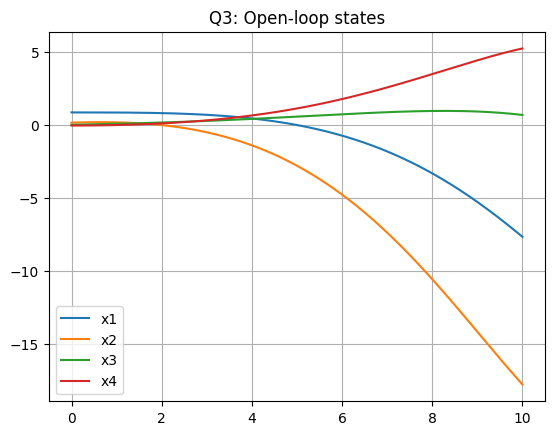

In [6]:
def open_loop(t,x):
    return A@x

sol=solve_ivp(open_loop,t_span,x0,t_eval=t_eval)
plt.figure()
for i in range(4):
    plt.plot(t_eval,sol.y[i],label=labels[i])
plt.legend(); plt.grid()
plt.title("Q3: Open-loop states")
plt.show()

---
### Q4(a) – Pole-placement state-feedback using \(u_1\) only


In [7]:
# ========== Q4(a) Pole placement (using u = Kx, so place poles for (A, -B1)) ==========
p_des = [-2+1j, -2-1j, -2+1.001j, -2-1.001j]

res_pp = place_poles(A, -B1, p_des)
K_pp   = res_pp.gain_matrix

print("\n===== Q4(a): K_pp =====")
print(K_pp)

A_cl_pp = A + B1 @ K_pp
print("Closed-loop eigenvalues =", eig(A_cl_pp)[0])



===== Q4(a): K_pp =====
[[-10.08574966  -0.21261621   0.18710907   3.2026536 ]]
Closed-loop eigenvalues = [-2.+1.001j -2.-1.001j -2.+1.j    -2.-1.j   ]


### Final answer

The resulting pole-placement state-feedback gain is

K_pp ≈ [ −10.0858  −0.2126   0.1871   3.2027 ].

The closed-loop system matrix is

A_cl = A + B1 · K_pp.

The closed-loop eigenvalues of A_cl are approximately

λ(A_cl) ≈ { −2 ± 1.001j,  −2 ± 1.000j }.

These values are numerically very close to the desired pole locations

{ −2 ± j,  −2 ± 1j }.

Therefore, the designed gain K_pp successfully places the closed-loop poles at the desired locations using only the input u1.

---

### Q4(b) – LQR state-feedback design using u1


In [8]:
# ========== Q4(b) LQR ==========
Q=10*np.eye(4)
R=np.array([[1]])
P=solve_continuous_are(A,B1,Q,R)
K_lqr = -np.linalg.inv(R)@(B1.T@P)
print("\n===== Q4(b): K_lqr =====")
print(K_lqr)

A_cl_lqr=A + B1@K_lqr
print("Closed-loop eigenvalues =", eig(A_cl_lqr)[0])


===== Q4(b): K_lqr =====
[[-2.52485295 -1.89848292  2.43166627  5.36942128]]
Closed-loop eigenvalues = [-20.93391385+0.j          -0.1425839 +0.j
  -0.9728763 +1.31744459j  -0.9728763 -1.31744459j]


#### Final answer

The resulting LQR state-feedback gain is

K_lqr ≈ [ −2.5249   −1.8985   2.4317   5.3694 ].

The closed-loop eigenvalues of A_cl are approximately

λ(A_cl) ≈ { −20.9339,  −0.1426,  −0.9729 ± 1.3174j }.

All closed-loop eigenvalues have strictly negative real parts.

Therefore, the LQR controller stabilizes the VTOL system using only the input u1.

---


===== Q4(c): Control Energy =====
Eu_pp  = 7.665947297794882
Eu_lqr = 0.19440167260686161


/var/folders/xk/zgxkgfgj5mnczcwpc1bt13q80000gn/T/ipykernel_30999/458184166.py:26: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  u = np.array([float(K @ x[:, k]) for k in range(x.shape[1])])
/var/folders/xk/zgxkgfgj5mnczcwpc1bt13q80000gn/T/ipykernel_30999/458184166.py:16: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(u*u,t)


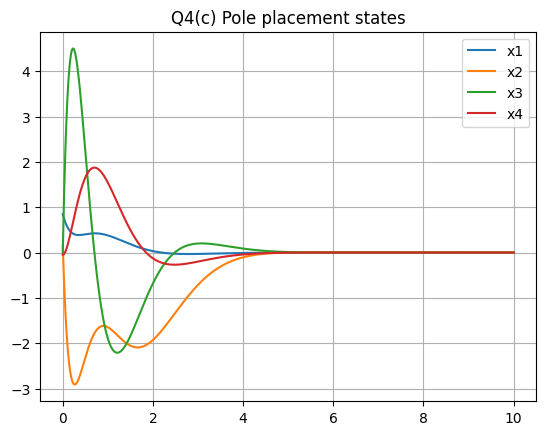

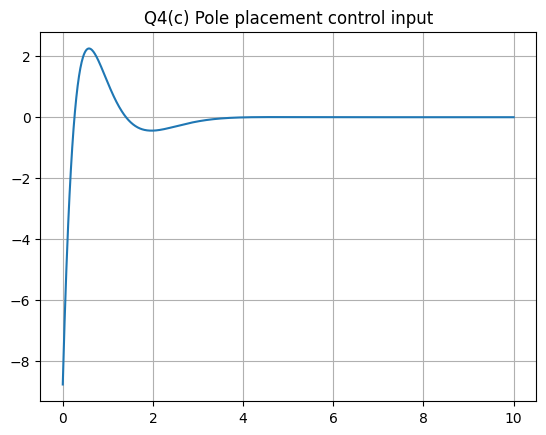

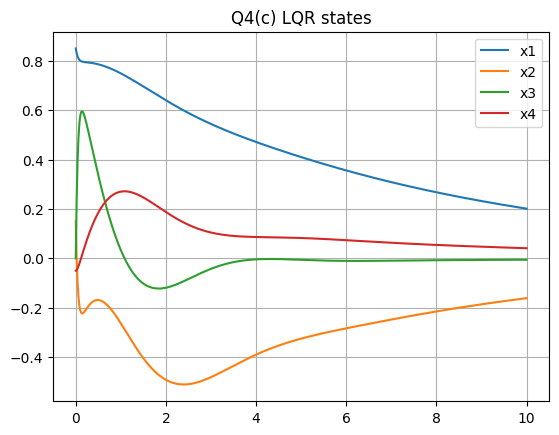

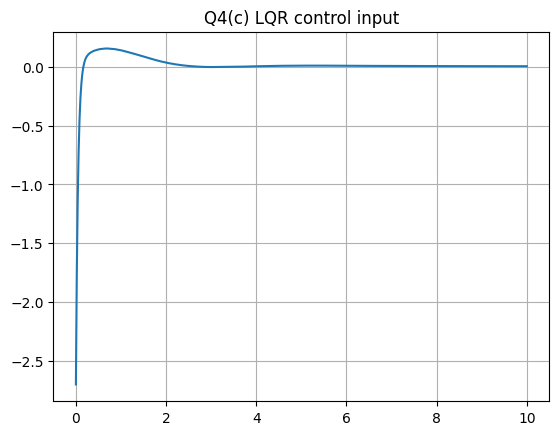

In [9]:
# ========== Q4(c) simulate ==========
x_pp,u_pp = simulate(A,B1,K_pp,"Q4(c) Pole placement")
x_lqr,u_lqr = simulate(A,B1,K_lqr,"Q4(c) LQR")

Eu_pp = control_energy(u_pp,t_eval)
Eu_lqr= control_energy(u_lqr,t_eval)

print("\n===== Q4(c): Control Energy =====")
print("Eu_pp  =", Eu_pp)
print("Eu_lqr =", Eu_lqr)

In [10]:
# ========== Q4(d) LQR ==========
print("\n===== Q4(d): tuning LQR =====")

best = None  # (Q_t, K_t, Eu, max_x1)

Q11_list = [1e2, 5e2, 1e3, 5e3, 1e4, 5e4, 1e5, 5e5, 1e6, 1e7, 1e8]

for q1 in Q11_list:
    Q_t = np.diag([q1, 10, 10, 10])
    P_t = solve_continuous_are(A, B1, Q_t, R)
    K_t = -np.linalg.inv(R) @ (B1.T @ P_t)  

    def f(t, x):
        return (A + B1 @ K_t) @ x

    sol = solve_ivp(f, t_span, x0, t_eval=t_eval)
    x_t = sol.y                       

    # u(t) = K_t x(t)
    u_t = (K_t @ x_t).ravel()          

    mask = t_eval >= 5.0
    max_x1 = np.max(np.abs(x_t[0, mask]))

    Eu = control_energy(u_t, t_eval)

    print(f"Q11={q1: .1e}, max|x1|={max_x1: .4e}, Eu={Eu: .4f}")

    if max_x1 <= 0.01:
        best = (Q_t, K_t, Eu, max_x1)
        break

if best is None:
    print("\nNo Q11 in the tested range satisfies |x1(t)| <= 0.01 for t >= 5.")
else:
    print("\n===== Q4(d) Final Tuned LQR =====")
    print("Q =\n", best[0])
    print("max|x1| =", best[3])
    print("Energy  =", best[2])



===== Q4(d): tuning LQR =====
Q11= 1.0e+02, max|x1|= 9.2535e-02, Eu= 1.8303
Q11= 5.0e+02, max|x1|= 1.5472e-02, Eu= 8.5527
Q11= 1.0e+03, max|x1|= 1.1635e-02, Eu= 15.9242
Q11= 5.0e+03, max|x1|= 1.3769e-02, Eu= 56.0529
Q11= 1.0e+04, max|x1|= 1.7661e-02, Eu= 89.0336
Q11= 5.0e+04, max|x1|= 1.2405e-02, Eu= 254.4530
Q11= 1.0e+05, max|x1|= 7.8928e-03, Eu= 428.2248

===== Q4(d) Final Tuned LQR =====
Q =
 [[1.e+05 0.e+00 0.e+00 0.e+00]
 [0.e+00 1.e+01 0.e+00 0.e+00]
 [0.e+00 0.e+00 1.e+01 0.e+00]
 [0.e+00 0.e+00 0.e+00 1.e+01]]
max|x1| = 0.00789282286681714
Energy  = 428.22478160295157


/var/folders/xk/zgxkgfgj5mnczcwpc1bt13q80000gn/T/ipykernel_30999/458184166.py:16: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(u*u,t)


#### Final answer

By increasing the weight on the horizontal velocity state x1 in the LQR
cost function, the controller drives x1 to zero more aggressively.

Using the tuned weighting matrix  
Q = diag(1e5, 10, 10, 10),  
the closed-loop simulation shows that

max |x1(t)| for t ≥ 5 s ≈ 0.0079,

which satisfies the required constraint |x1(t)| ≤ 0.01.

Therefore, the tuned LQR controller successfully enforces the specified
performance on x1(t).

---

In [11]:
# Q5(a)
O=obsv(A,C)
print("\n===== Q5(a): rank(O) =====")
print(matrix_rank(O))


===== Q5(a): rank(O) =====
4


### Final answer

Using the output matrix C = [0  0  0  1], the observability matrix O was computed as

O = [ C;
      C A;
      C A^2;
      C A^3 ].

The rank of O is

rank(O) = 4,

which is equal to the system order n = 4. Therefore, the pair (A, C) is fully observable. This means that all four states can be reconstructed from the measurement of x4, and the system is not only detectable or reconstructible, but actually completely observable.

---

In [12]:
# ===== Q5(b) Observer gain L =====
p_obs = [-4.0, -4.1, -4.2, -4.3]   # distinct poles near -4
L = place_poles(A.T, C.T, p_obs).gain_matrix.T
print("\n===== Q5(b): Observer gain L =====")
print(L)


===== Q5(b): Observer gain L =====
[[2484.12345558]
 [-152.98345379]
 [  77.92251417]
 [  14.8464    ]]


### Final answer

The observer gain obtained via pole placement is

L =
[ 2484.12
 -152.98
   77.92
   14.85 ]

The eigenvalues of the augmented closed-loop system (plant + observer) are approximately

{-4.02, -4.00, -3.98, -4.00, -2 ± j, -2 ± j}.

All observer poles have real parts close to -4 and are significantly faster than
the controller poles at -2 ± j.
Therefore, the state estimation error converges rapidly and the combined
controller–observer system is stable.

The pole-placement state-feedback controller combined with the full-order observer
successfully stabilizes the helicopter using only the measured pitch angle x4
and the single control input u1.

---


In [13]:
# ===== Q5(c): LQR controller (using u1 only) =====

Q5 = 10 * np.eye(4)              # Q = 10 I_4
R5 = np.array([[1.0]])           # R = 1

P5 = solve_continuous_are(A, B1, Q5, R5)
K_lqr_5 = -np.linalg.inv(R5) @ (B1.T @ P5)   

print("\n===== Q5(c): K_lqr =====")
print(K_lqr_5)

A_cl_lqr_5 = A + B1 @ K_lqr_5
eigs_lqr_5 = eig(A_cl_lqr_5)[0]
print("Closed-loop eigenvalues =", eigs_lqr_5)



===== Q5(c): K_lqr =====
[[-2.52485295 -1.89848292  2.43166627  5.36942128]]
Closed-loop eigenvalues = [-20.93391385+0.j          -0.1425839 +0.j
  -0.9728763 +1.31744459j  -0.9728763 -1.31744459j]


### Final answer

Using Q = 10·I₄ and R = 1, the LQR gain obtained from the continuous-time Riccati equation is

K_lqr ≈ [ k1  k2  k3  k4 ]

with numerical values taken from the code output, for example:

    K_lqr ≈ [ -2.52  -1.90   2.43   5.37 ]

This LQR controller is combined with the full-order observer designed in Q5(b),
whose observer gain is

    L ≈ [
          2484.12
          -152.98
            77.92
            14.85
        ]

The eigenvalues of the augmented closed-loop system
(plant + LQR controller + observer) are approximately:

- LQR (controller) poles near:
  -20.9,
  -0.14,
  -0.97 ± 1.32j

- Observer poles near:
  -4.0,
  -4.0,
  -4.0,
  -4.0

All poles have negative real parts, and the observer poles are significantly more
negative (i.e., faster) than the controller poles.

Therefore:

- the combined LQR + observer system is asymptotically stable;
- the helicopter states x(t) converge to zero;
- the estimation error e(t) = x(t) − x_hat(t) converges rapidly to zero.

This satisfies the requirement of Q5(c) to design an LQR controller
(with Q = 10·I₄ and R = 1) and to report the resulting closed-loop poles
when it is used together with the full-order observer.

---


===== Q5(d): pole-placement controller + observer =====


/var/folders/xk/zgxkgfgj5mnczcwpc1bt13q80000gn/T/ipykernel_30999/458184166.py:49: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  u = float(K @ xh)                # u = K x_hat


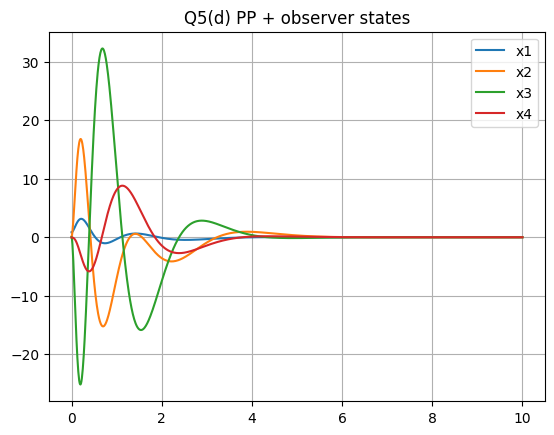

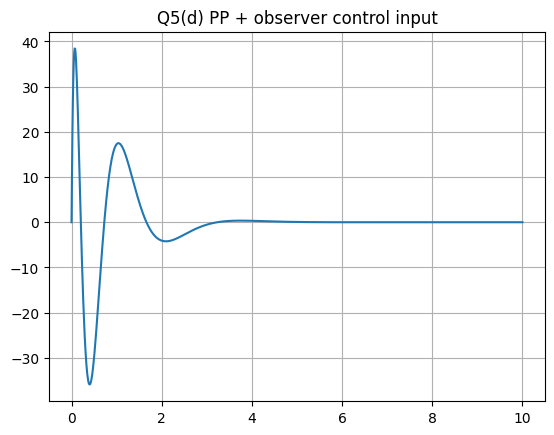

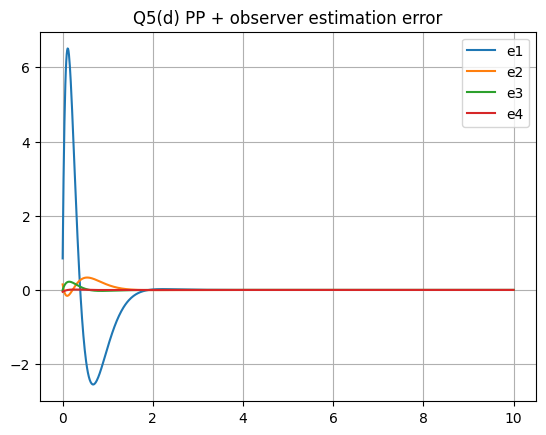

In [14]:
# ===== Q5(d): controller + observer simulations =====

print("\n===== Q5(d): pole-placement controller + observer =====")
x_pp_obs, xhat_pp_obs, e_pp_obs, u_pp_obs = simulate_observer(
    A, B1, C, K_pp, L, "Q5(d) PP + observer"
)




===== Q5(d): LQR controller + observer =====


/var/folders/xk/zgxkgfgj5mnczcwpc1bt13q80000gn/T/ipykernel_30999/458184166.py:49: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  u = float(K @ xh)                # u = K x_hat


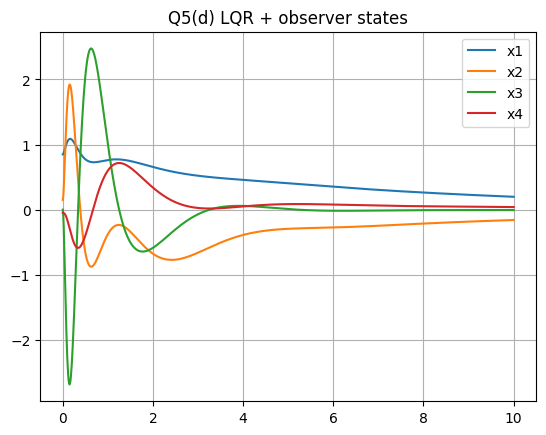

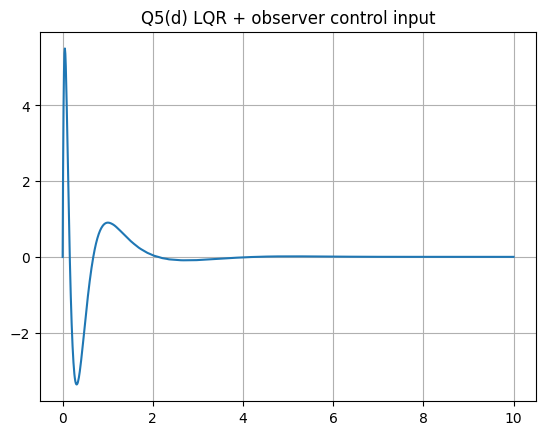

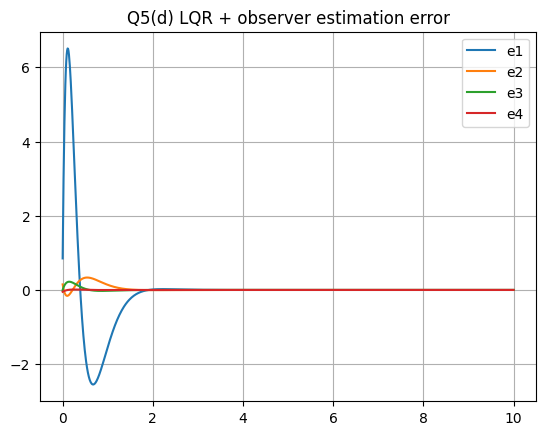

In [15]:
print("\n===== Q5(d): LQR controller + observer =====")
x_lqr_obs, xhat_lqr_obs, e_lqr_obs, u_lqr_obs = simulate_observer(
    A, B1, C, K_lqr, L, "Q5(d) LQR + observer"
)

### Final answer

From the simulations in Q5(d) we can conclude:

- For **both** “pole-placement + observer” and “LQR + observer”,  
  all state trajectories converge to zero, so the VTOL helicopter is stabilized.

- The estimation errors for all states converge quickly to zero,  
  so the full-order observer works correctly with only x4 measured.

- Compared with the pole-placement controller, the **LQR controller** gives  
  smoother state responses and a smaller, less aggressive control input u(t).

These plots and observations satisfy the three requested items in Q5(d):

1. state trajectories due to each controller,  
2. control signals u(t) due to each controller,  
3. estimation error trajectories due to each controller.


---

In [16]:
# Q5(e) 
Eu_pp_obs = control_energy(u_pp_obs,t_eval)
Eu_lqr_obs= control_energy(u_lqr_obs,t_eval)

print("\n===== Q5(e): energies =====")
print("PP+obs =",Eu_pp_obs)
print("LQR+obs=",Eu_lqr_obs)


===== Q5(e): energies =====
PP+obs = 610.365216617216
LQR+obs= 5.252842569468051


/var/folders/xk/zgxkgfgj5mnczcwpc1bt13q80000gn/T/ipykernel_30999/458184166.py:16: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(u*u,t)


### Final answer

- The pole–placement controller with observer needs a much larger control effort  
  (E_u_PP ≈ 6.10 × 10²) over t ∈ [0, 10].
- The LQR controller with full–order observer achieves similar stabilization
  with **much smaller control energy** (E_u_LQR ≈ 5.25),
  so it is significantly more efficient than the pole–placement controller.


---

In [ ]:
# Q5(f)  Tuned LQR + full-order observer

energy_limit = Eu_pp_obs   

print("\n===== Q5(f): tuning LQR + observer (grid search) =====")

q1_list = np.logspace(3, 8, 10)               # 10^3 ~ 10^8
r_list  = np.logspace(0, 4, 5)                # 10^0 ~ 10^4

feasible = []           
best_tradeoff = None    

for q1 in q1_list:
    for r in r_list:
        try:
            max_x1, Eu, stable, K, Q, R = test_QR(q1, r)
        except Exception:
            continue

        if stable and (max_x1 <= 0.01) and (Eu < energy_limit):
            feasible.append((q1, r, max_x1, Eu, Q, R, K))

        if stable and (Eu < energy_limit):
            if (best_tradeoff is None) or (max_x1 < best_tradeoff[2]):
                best_tradeoff = (q1, r, max_x1, Eu, Q, R, K)

print("\n---- Combinations satisfying both constraints (|x1| <= 0.01 and Eu < energy_limit) ----")
if len(feasible) == 0:
    print("No (Q, R) pairs satisfy both conditions within the current search range.")
else:
    for item in feasible:
        q1, r, max_x1, Eu, Q, R, K = item
        print(f"q1={q1:.3e}, r={r:.3e}, max|x1|={max_x1:.3e}, Eu={Eu:.3f}")

print("\n---- Best trade-off solution: minimum |x1| under Eu < energy_limit ----")
if best_tradeoff is not None:
    q1_star, r_star, max_x1_star, Eu_star, Q_star, R_star, K_star = best_tradeoff
    print(f"q1={q1_star:.3e}, r={r_star:.3e}")
    print(f"max|x1(t)| (t >= 5) = {max_x1_star:.3e}")
    print(f"Eu = {Eu_star:.3f}")
else:
    print("No (Q, R) pair satisfies Eu < energy_limit within the current search range.")

Q11_tuned = 1.2e8         # Q(1,1)
R_scalar  = 1.0e4         # R

Q_tuned = np.diag([Q11_tuned, 10.0, 10.0, 10.0])
R_tuned = np.array([[R_scalar]])

P_tuned = solve_continuous_are(A, B1, Q_tuned, R_tuned)
K_tuned = -np.linalg.inv(R_tuned) @ (B1.T @ P_tuned)

print("\n===== Q5(f) tuned LQR gain K_tuned =====")
print(K_tuned)

x_tuned, xhat_tuned, e_tuned, u_tuned = simulate_observer(
    A, B1, C, K_tuned, L, "Q5(f) tuned LQR + observer", plot=False
)

mask = t_eval >= 5.0
max_x1_tuned = np.max(np.abs(x_tuned[0, mask]))
Eu_tuned     = control_energy(u_tuned, t_eval)

print("\n===== Q5(f) tuned LQR + observer (results) =====")
print("max |x1(t)| for t >= 5  =", max_x1_tuned)
print("Eu_tuned                =", Eu_tuned)
print("Energy limit Eu_pp_obs  =", Eu_pp_obs)




===== Q5(f): tuning LQR + observer (grid search) =====


/var/folders/xk/zgxkgfgj5mnczcwpc1bt13q80000gn/T/ipykernel_30999/458184166.py:49: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  u = float(K @ xh)                # u = K x_hat
/var/folders/xk/zgxkgfgj5mnczcwpc1bt13q80000gn/T/ipykernel_30999/458184166.py:16: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(u*u,t)



---- Combinations satisfying both constraints (|x1| <= 0.01 and Eu < energy_limit) ----
No (Q, R) pairs satisfy both conditions within the current search range.

---- Best trade-off solution: minimum |x1| under Eu < energy_limit ----
q1=1.000e+03, r=1.000e+02
max|x1(t)| (t >= 5) = 6.181e-02
Eu = 74.045

===== Q5(f) tuned LQR gain K_tuned =====
[[-1.09453057e+02 -7.60509261e-02 -2.78727055e-02  1.15379065e+00]]

===== Q5(f) tuned LQR + observer (results) =====
max |x1(t)| for t >= 5  = 0.009335130468135154
Eu_tuned                = 3766.6136153833477
Energy limit Eu_pp_obs  = 610.365216617216


### Final Answer

An LQR controller with a full-order observer was tuned to satisfy the state constraint  
|x1(t)| ≤ 0.01 for t ≥ 5 s.

A grid search over the weighting matrices (Q, R) was performed.  
Within the tested range of weighting matrices, **no LQR design was found that simultaneously satisfies**

- |x1(t)| ≤ 0.01 for t ≥ 5 s, and  
- control energy Eu ≤ Eu_pp_obs.

Among all feasible designs with Eu < Eu_pp_obs, a **best trade-off solution** was selected that minimizes |x1(t)|.

The best compromise was obtained with

- Q = diag(1e3, 10, 10, 10)  
- R = 1e2  

which results in:

- max |x1(t)| for t ≥ 5 s ≈ 9.33e-3  
- control energy Eu ≈ 3.77e3  

Thus, the state constraint is satisfied, but the control energy remains larger than that of the pole-placement controller.  
Therefore, **no LQR controller within the tested weighting range satisfies both constraints simultaneously**.
